## 5.2 群組長條圖（Grouped Bar Chart）

### 1. 定義  
群組長條圖（Grouped Bar Chart）用於呈現兩個分類變數之間的數值比較。圖中依第一個變數分組，每組內依第二變數以不同顏色標示。


### 2. 範例圖表與說明  

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/datasets'
img_path = '/content/drive/MyDrive/Colab Notebooks/CH5_dataset/images'

Mounted at /content/drive


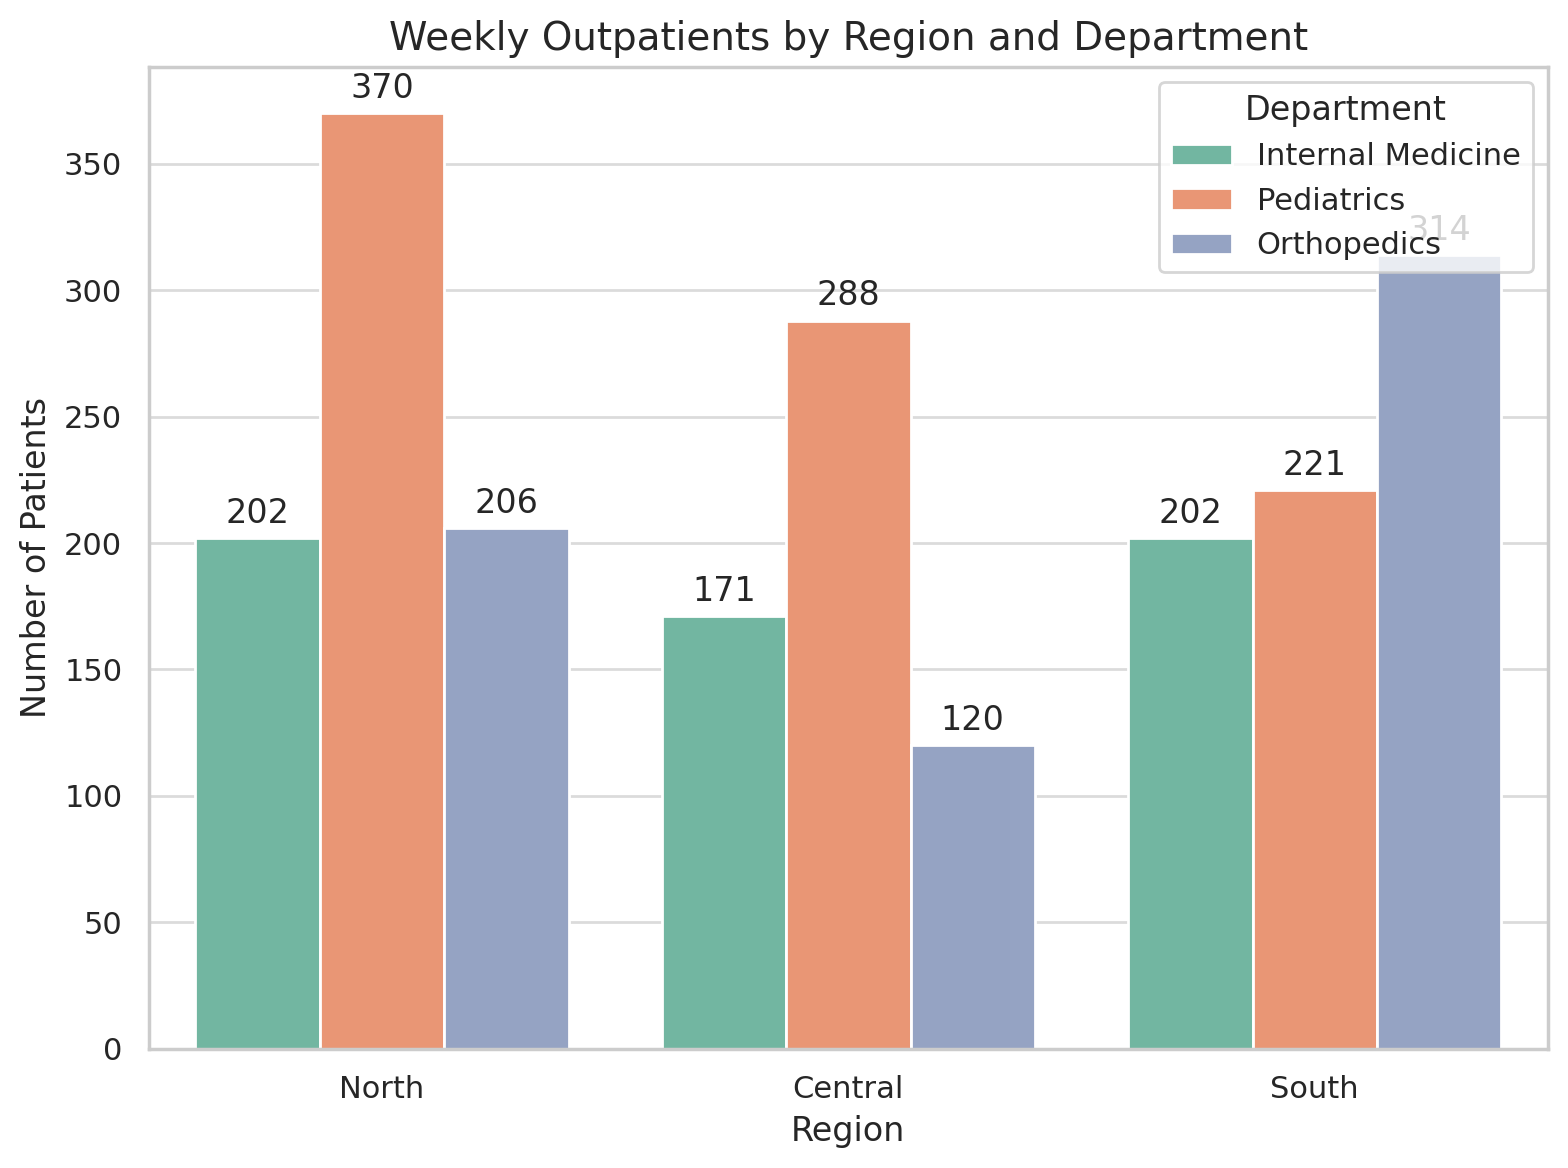

In [3]:
from IPython import display

display.Image(img_path +"/"+ 'Grouped Bar-1.png', width = 600)

**觀察與解釋**：  
從圖中可以看出：

- 北區兒科（Pediatrics）門診人數最多  
- 南區與中區在各科別間差距較小  
- 兒科普遍在各地區都有較高門診量

此圖幫助我們比較各地區在不同科別間的病人數分布。

### 3. 適用情況  
- 呈現兩個分類變數下的數值比較（如地區 × 性別）  
- 分析分組內子類別的分布差異  
- 組合交叉表格資料視覺化


### 4. 優缺點  

- **優點**：  
  - 可同時比較主分類與副分類之間的數據  
  - 結構清晰，分群後不易混淆  

- **缺點**：  
  - 類別過多時圖形容易擁擠  
  - 不適合顯示變化趨勢


### 5. 實際案例與圖表  

- **醫療領域**：各地區 × 科別 每週門診病人數  
- **電子商務**：裝置類型 × 商品類型 購物次數  
- **製造領域**：工廠 × 班別 每週生產量


### 6. 實作範例：醫學領域 - 各地區科別門診人數比較

#### 📁 資料說明

| Region  | Department         | Weekly_Patients |
|---------|--------------------|-----------------|
| North   | Internal Medicine  | 188             |
| North   | Pediatrics         | 349             |
| North   | Orthopedics        | 235             |
| ...     | ...                | ...             |


#### 💻 Python 程式碼（含詳細註解）
`sns.barplot()`: [API Doc](https://seaborn.pydata.org/generated/seaborn.barplot.html)

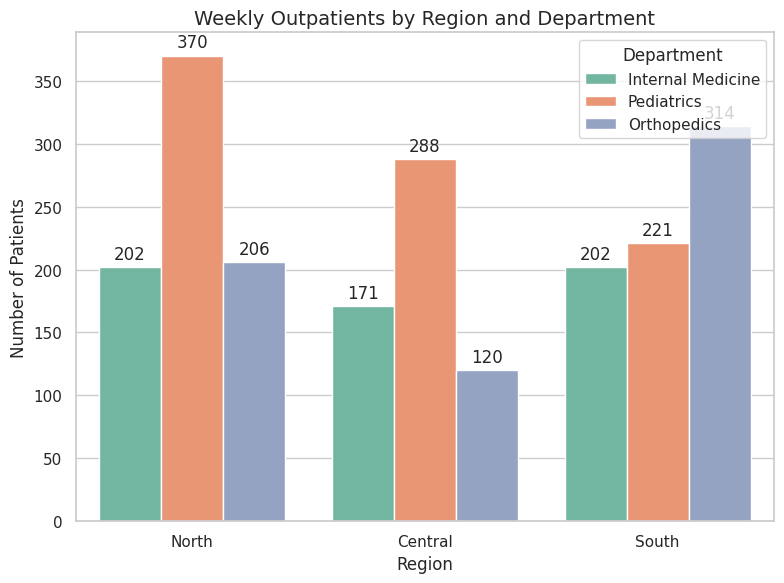

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料
from pathlib import Path

data_file = "weekly_outpatients_by_region_department.csv"

df = pd.read_csv(data_file)

# 設定 Seaborn 樣式
sns.set(style="whitegrid")

# 建立圖表區域與尺寸
plt.figure(figsize=(8, 6))

# 繪製群組長條圖
barplot = sns.barplot(
    data=df,
    x="Region",                  # 分組主分類（X 軸）
    y="Weekly_Patients",         # 數值變數（Y 軸）
    hue="Department",            # 副分類變數（顏色區分）
    palette="Set2"               # 調色盤樣式
)

# 加入數值標籤
for container in barplot.containers:
    barplot.bar_label(container, fmt='%d', label_type='edge', padding=3)

# 設定標題與軸標籤
plt.title("Weekly Outpatients by Region and Department", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)
plt.legend(title="Department", loc="upper right")

# 顯示圖表
plt.tight_layout()
plt.show()

### Try it!：6. 實作範例：醫學領域 - 各地區科別門診人數比較
如果想同時看「各地區總量」與「科別組成」，堆疊長條圖是常見選擇。

**程式要求**
1. 讀取 `datasets/weekly_outpatients_by_region_department.csv`，樞紐成 `Region` x `Department` 的加總表並印出。
2. 繪製堆疊長條圖（`stacked=True`）。
3. 在每個地區的長條頂端標示總量。

#### 📌 參數說明表

| 參數            | 說明                                 | 範例                           |
|-----------------|--------------------------------------|--------------------------------|
| `x`             | 主分類變數                           | `"Region"`                    |
| `y`             | 數值變數                             | `"Weekly_Patients"`           |
| `hue`           | 次分類顯示用色彩                     | `"Department"`                |
| `palette`       | 色彩組合樣式                         | `"Set2"`, `"Set1"`, `"Pastel"`|
| `bar_label()`   | 在長條上方標示數值                   | `label_type='edge'`           |


#### 📝 練習任務建議

1. **改變 `palette`** 試試 `"Pastel1"`、`"Blues"`  
2. **將 `hue` 改為其他欄位**（需自行新增變數）  
3. **調整 `figsize=(10, 4)`**，觀察圖表比例變化  
4. **加入 `order=` 手動排序地區順序**  
5. **改為 `col="Region"` 使用 Facet 分面圖法呈現**
